# TẠO CÁC TẬP DỮ LIỆU TRAIN, TEST (SPLITS)

1. Yêu cầu chung: Tạo ra các splits, mỗi split tương ứng với một tập dữ liệu train - test
  + Bài học lý thuyết (để trả lời cho các câu hỏi như vì sao phải cần việc này, thực hiện việc này như thế nào):
    - https://www.kaggle.com/code/satishgunjal/tutorial-k-fold-cross-validation
    - https://machinelearningmastery.com/training-validation-test-split-and-cross-validation-done-right/
    - https://machinelearningmastery.com/how-to-configure-k-fold-cross-validation/

  <IMG SRC = 'https://raw.githubusercontent.com/satishgunjal/images/master/KFold_Cross_Validation.png'>
  
2. Yêu cầu cụ thể:
- Input:
    + Thư mục cha chứa các thư mục con - mỗi thư mục con tương ứng với tên của từng hiệu xe (Honda, Suzuki, VinFast, Yamaha, Others). Ví dụ: https://drive.google.com/drive/u/1/folders/1Uj0V9URNHpzSHeXHSB89AoGCjGki8Yra
    + Các ảnh được đặt tên theo quy ước: các tập tin ảnh theo quy ước
    + Số splits NumSplits - mặc định NumSplits=5 (tương đương 5-fold CV)
- Output:
    + File CarDataset.csv - Tập tin chứa tất cả ảnh của dataset
      - Chương trình sẽ scan qua cây thư mục để tìm tất cả các ảnh (chỉ chọn các ảnh có định dạng + phần mở rộng là .jpg)
      - Mỗi dòng sẽ có các thông tin cách nhau bằng dấu phẩy, theo quy ước: ImageFullPath, CategoryID
            - ImageFullPath ở dạng <Thư mục Hiệu xe>/<Tên ảnh>. Ví dụ: Honda/2024123.Honda.1.jpg.
            - CategoryID là số nguyên thuộc [0..5] theo quy ước
              - 0: Others
              - 1: Honda
              - 2: Suzuki
              - 3: Yamaha
              - 4: VinFast     
    + File CarDataset-Splits-[1..5]-[Train/Test].csv - Phân chia thành các splits, mỗi split gồm các ảnh được chia thành thành 2 tập Train - Test
      + Chương trình sẽ đọc dữ liệu từ file CarDataset.csv, sau đó với mỗi hiệu xe, chia ngẫu nhiên thành 5 tập dữ liệu. Lưu ý là phải chia theo hiệu xe, để đảm bảo dữ liệu Train/Test có dữ liệu của các hiệu xe.
      + Từ 5 tập dữ liệu chia ngẫu nhiên theo các hiệu xe Xij (i là thứ tự tập dữ liệu, j là CategoryID), gom lại thành 5 tập dữ liệu lớn hơn Xi, sao cho mỗi tập dữ liệu này chứa đủ dữ liệu của tất cả các hiệu xe. Tức là Xi = Union(Xij)       
      + Từ 5 tập dữ liệu Xi này (tương ứng với FOLDi ở trong hình vẽ trên), tạo ra 5 splits Split-i
      + Với mỗi bộ dữ liệu Split-i, ghi xuống thành 2 tập tin tương ứng với Train, Test. Ví dụ Split-1 thì ghi thành tập tin  CarDataset-Splits-1-Train.csv và CarDataset-Splits-1-Test.csv. Tập Train gồm 4 bộ, Test gồm bộ còn lại. Ví dụ,
          + Split-1: tập Train sẽ gồm X2, X3, X4, X5, tập Test là X1
          + Split-5: tập Train sẽ gồm X1, X2, X3, X4, tập Test là X5
      + Mỗi dòng sẽ có các thông tin cách nhau bằng dấu phẩy, theo quy ước: ImageFullPath, CategoryID
- Lưu ý:
  - Nên viết thêm các cell
    - Hiển thị danh sách các tên tập tin ảnh trong từng Split-Train/Test,
    - Thống kê các ảnh cho từng CategoryID trong mỗi Split-Train/Test
  - Cần có chú thích
3. Nộp bài: SV share notebook. Các bài nộp sớm sẽ được full điểm. Deadline: TBA
4. Bài làm đạt yêu cầu sẽ được paste vào notebook với ghi nhận đóng góp từ tác giả.

## Thông tin của tác giả, ngày cập nhật
- Lưu Đoàn Ngọc Phát - 22521070
- Huỳnh Danh Đạt - 22520211

# Import Library

In [ ]:
import os
import pandas as pd
import numpy as np
import csv
from collections import defaultdict
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Create Dataset CSV

In [ ]:
#dir = "data"
dir = "/content/drive/MyDrive/Public"
# Danh sách folder
fol = ["Others","Honda","Hyundai","KIA","Mazda","Mitsubishi","Suzuki","Toyota","VinFast"]


# Tạo file cardataset gồm đường dẫn tất cả các file hình ảnh
with open("CarDataset.csv", "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["ImageFullPath", "CategoryID"])
    for idx,subfol in enumerate(fol):
        fol_dir =os.path.join(dir,subfol)
        for file in os.listdir(fol_dir):
            if file.endswith('jpg'):
                writer.writerow([f"{subfol}/{file}",idx])


In [ ]:
import pandas as pd
df = pd.read_csv('CarDataset.csv')
df

,ImageFullPath,CategoryID
0,Others/22520394-22520395.Others.129.jpg,0
1,Others/22520394-22520395.Others.130.jpg,0
2,Others/22520394-22520395.Others.131.jpg,0
3,Others/22520394-22520395.Others.132.jpg,0
4,Others/22520394-22520395.Others.133.jpg,0
...,...,...
35453,VinFast/22521027-22520195-22521060.VinFast.103...,8
35454,VinFast/22521027-22520195-22521060.VinFast.102...,8
35455,VinFast/22521027-22520195-22521060.VinFast.102...,8
35456,VinFast/22521027-22520195-22521060.VinFast.103...,8


# Chia Fold Bằng KFold

In [ ]:
from sklearn.model_selection import KFold
# Chia 5 fold và lưu vào csv
def splitting(df, num = 5):
  kf = KFold (n_splits=num, shuffle=True, random_state=42)
  for fold, (train_index, text_index) in enumerate(kf.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[text_index]
    #print(train)
    #print(test)
    train.to_csv(f'CarDataset-Splits-{fold}-Train.csv',sep=",", index=False)
    test.to_csv(f'CarDataset-Splits-{fold}-Test.csv',sep=",", index=False)

In [ ]:
splitting(df,num = 5)
t1 = pd.read_csv('CarDataset-Splits-1-Train.csv')
t1

,ImageFullPath,CategoryID
0,Others/22520394-22520395.Others.130.jpg,0
1,Others/22520394-22520395.Others.131.jpg,0
2,Others/22520394-22520395.Others.133.jpg,0
3,Others/22520394-22520395.Others.134.jpg,0
4,Others/22520394-22520395.Others.135.jpg,0
...,...,...
28361,VinFast/22521027-22520195-22521060.VinFast.102...,8
28362,VinFast/22521027-22520195-22521060.VinFast.102...,8
28363,VinFast/22521027-22520195-22521060.VinFast.102...,8
28364,VinFast/22521027-22520195-22521060.VinFast.103...,8


In [ ]:
# In mẫu 5 hàng đầu của từng fold trong các tập train, test
print('======================================================================================================')
for i in range(5):
    train = pd.read_csv(f'CarDataset-Splits-{i+1}-Train.csv')
    test = pd.read_csv(f'CarDataset-Splits-{i+1}-Test.csv')
    print(f"Fold {i+1}:")
    print("- Train: ")
    for _,row in train.head().iterrows():
        lines = ','.join(str(line) for line in row.to_list())
        print(lines)
    print("- Test: ")
    for _,row in train.head().iterrows():
        lines = ','.join(str(line) for line in row.to_list())
        print(lines)
    print('======================================================================================================')

Fold 1:
- Train: 
Others/22521070-22520211.Others.1.jpg,0
Others/22521070-22520211.Others.10.jpg,0
Others/22521070-22520211.Others.100.jpg,0
Others/22521070-22520211.Others.101.jpg,0
Others/22521070-22520211.Others.102.jpg,0
- Test: 
Others/22521070-22520211.Others.1.jpg,0
Others/22521070-22520211.Others.10.jpg,0
Others/22521070-22520211.Others.100.jpg,0
Others/22521070-22520211.Others.101.jpg,0
Others/22521070-22520211.Others.102.jpg,0
Fold 2:
- Train: 
Others/22521070-22520211.Others.1.jpg,0
Others/22521070-22520211.Others.10.jpg,0
Others/22521070-22520211.Others.101.jpg,0
Others/22521070-22520211.Others.102.jpg,0
Others/22521070-22520211.Others.103.jpg,0
- Test: 
Others/22521070-22520211.Others.1.jpg,0
Others/22521070-22520211.Others.10.jpg,0
Others/22521070-22520211.Others.101.jpg,0
Others/22521070-22520211.Others.102.jpg,0
Others/22521070-22520211.Others.103.jpg,0
Fold 3:
- Train: 
Others/22521070-22520211.Others.10.jpg,0
Others/22521070-22520211.Others.100.jpg,0
Others/22521070-2

# Sơ đồ phân bố dữ liệu

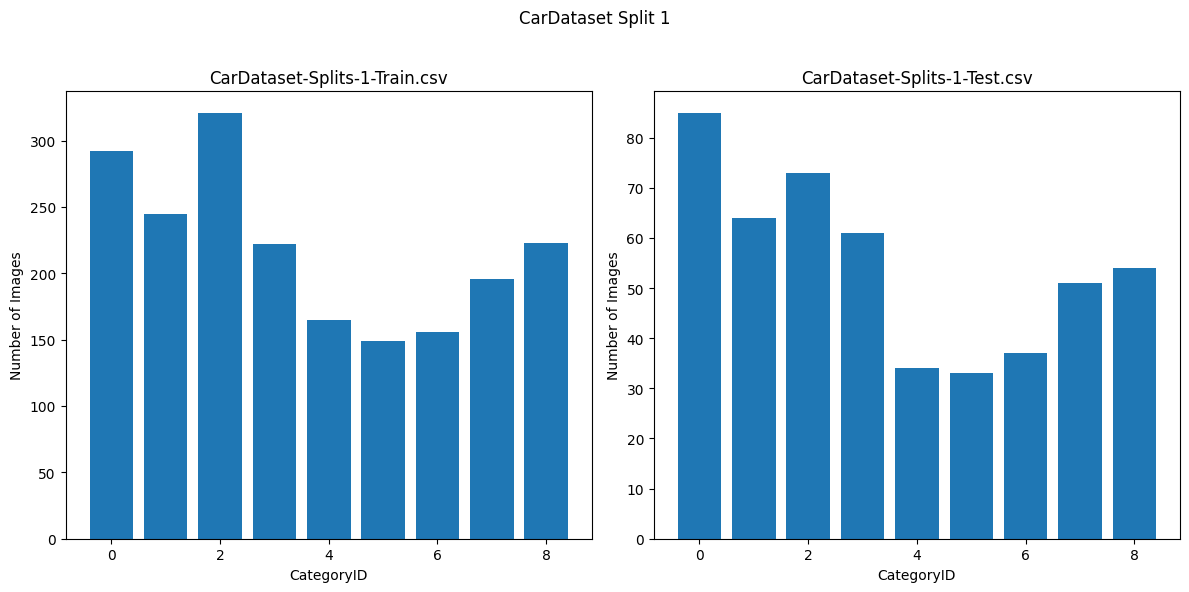

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def plot_category_statistics(split_files):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Tạo 2 biểu đồ con
    fig.suptitle(f"CarDataset Split 1")  # Tiêu đề chính cho toàn bộ biểu đồ

    for idx, split_file in enumerate(split_files):
        category_counts = Counter()  # Đếm số lượng ảnh cho từng CategoryID
        df = pd.read_csv(split_file, names=['ImageFullPath', 'CategoryID'])

        # Đảm bảo rằng cột 'CategoryID' chỉ chứa giá trị hợp lệ
        df['CategoryID'] = pd.to_numeric(df['CategoryID'], errors='coerce')
        df = df.dropna(subset=['CategoryID'])  # Loại bỏ giá trị NaN
        df['CategoryID'] = df['CategoryID'].astype(int)

        category_counts.update(df['CategoryID'])  # Đếm số lượng ảnh cho từng CategoryID

        # Chuyển Counter thành DataFrame
        stats_df = pd.DataFrame.from_dict(category_counts, orient='index', columns=['Count'])
        stats_df.index.name = 'CategoryID'
        stats_df.reset_index(inplace=True)

        # Plot số lượng ảnh cho từng CategoryID
        axes[idx].bar(stats_df['CategoryID'], stats_df['Count'])
        axes[idx].set_xlabel('CategoryID')
        axes[idx].set_ylabel('Number of Images')
        axes[idx].set_title(f'{split_file}')

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Điều chỉnh layout của các biểu đồ con
    plt.show()

# Danh sách các file CSV (split files)
split = 1
split_files = [f'CarDataset-Splits-{split}-Train.csv', f'CarDataset-Splits-{split}-Test.csv']
plot_category_statistics(split_files)



Có thể thấy ở cả hai tập train và test đều có sự phân bố ở các label giống nhau


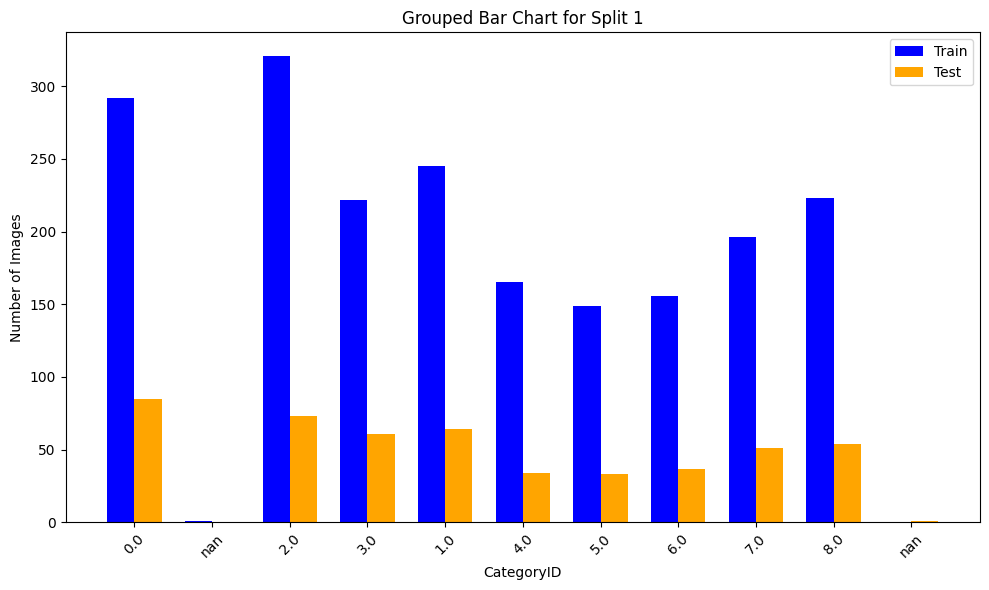

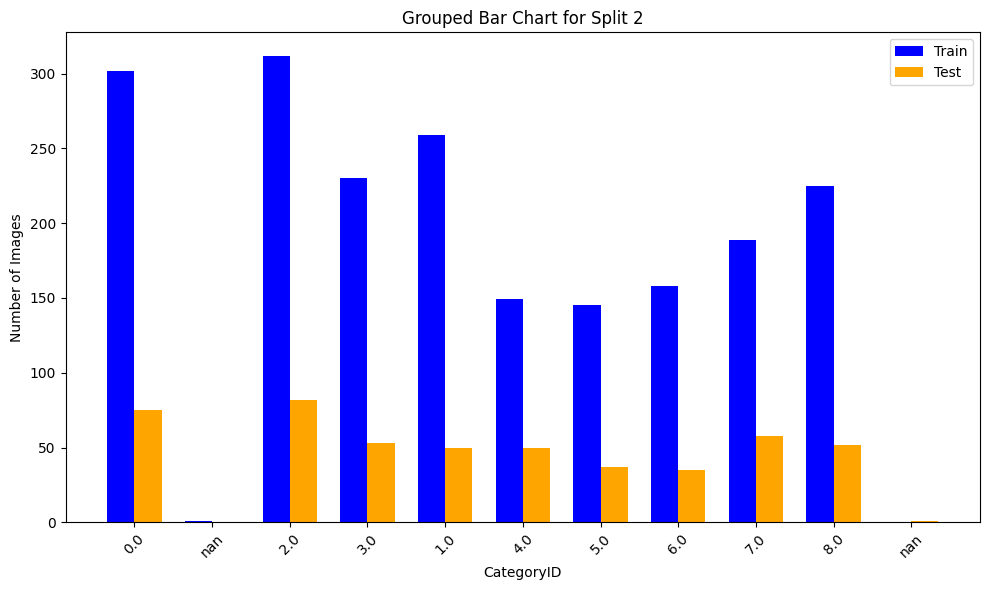

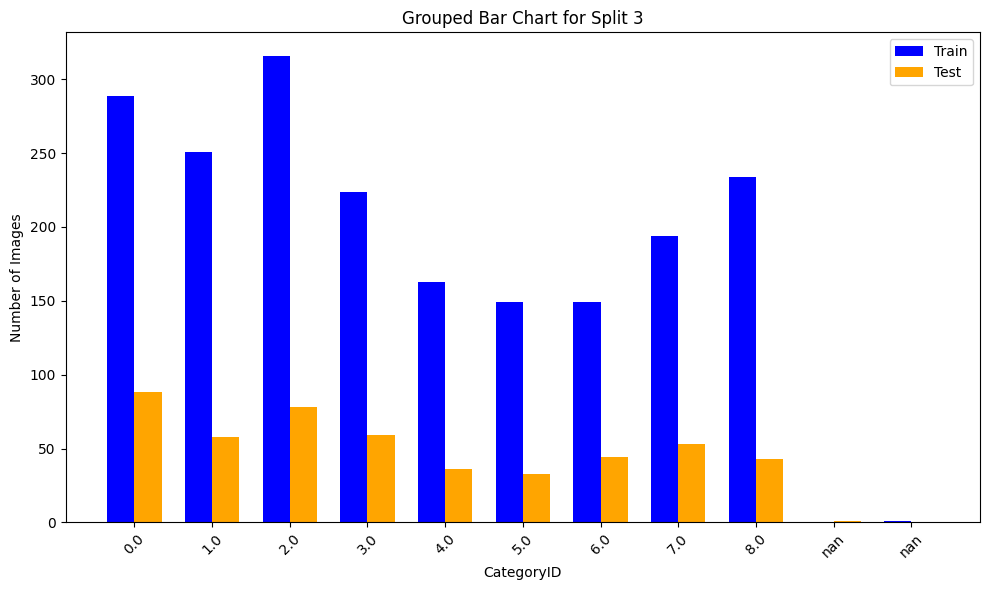

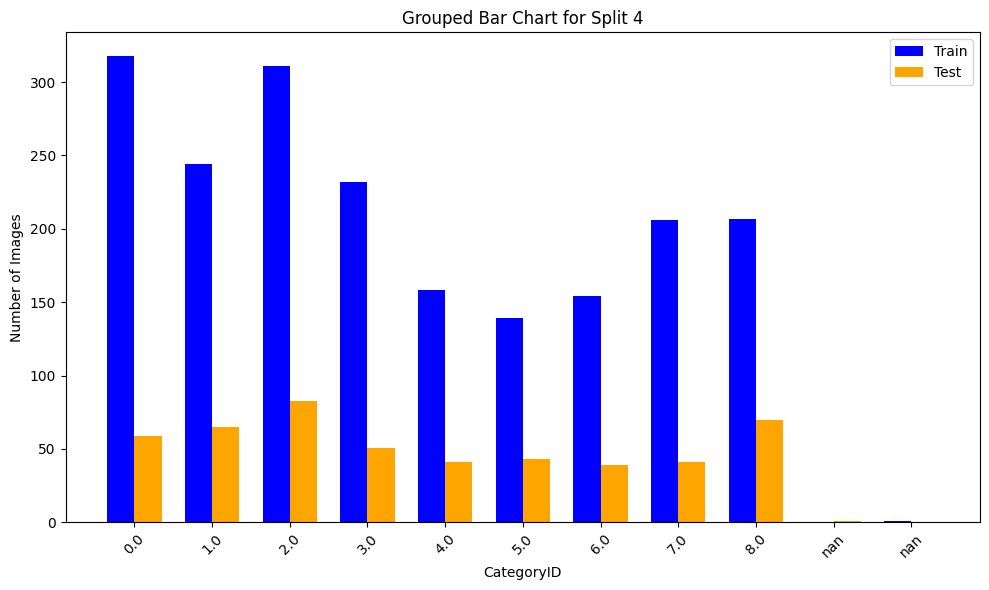

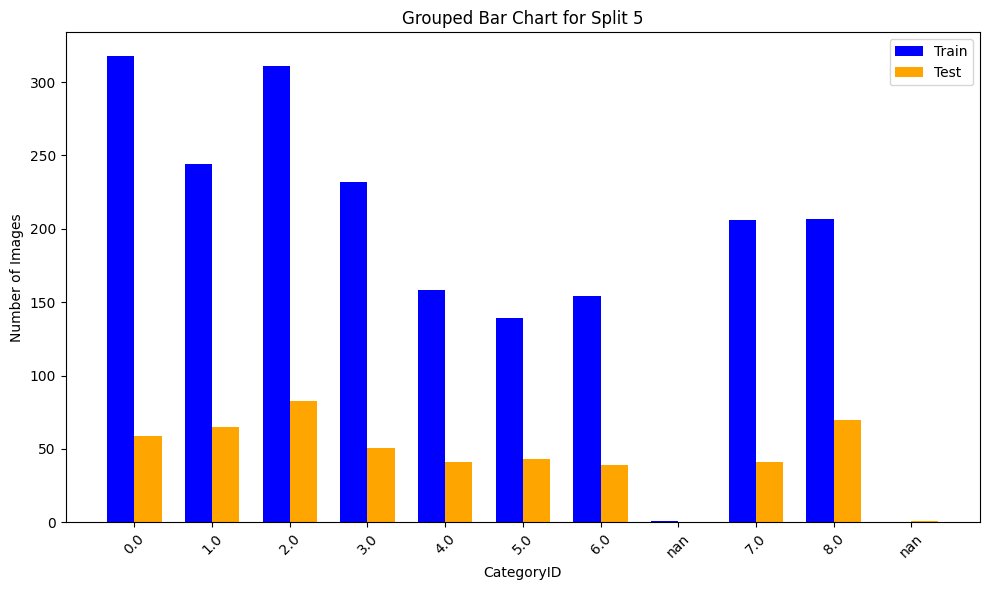

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def plot_split_grouped_bar_charts(folder_path, split_pairs):
    for split_name, (train_file, test_file) in split_pairs.items():
        # Đọc dữ liệu Train
        train_df = pd.read_csv(f"{folder_path}/{train_file}", names=['ImageFullPath', 'CategoryID'])
        train_df['CategoryID'] = pd.to_numeric(train_df['CategoryID'], errors='coerce').dropna().astype(int)
        train_counts = Counter(train_df['CategoryID'])

        # Đọc dữ liệu Test
        test_df = pd.read_csv(f"{folder_path}/{test_file}", names=['ImageFullPath', 'CategoryID'])
        test_df['CategoryID'] = pd.to_numeric(test_df['CategoryID'], errors='coerce').dropna().astype(int)
        test_counts = Counter(test_df['CategoryID'])

        # Kết hợp dữ liệu Train và Test
        all_categories = set(train_counts.keys()).union(test_counts.keys())
        train_values = [train_counts[cat] for cat in all_categories]
        test_values = [test_counts[cat] for cat in all_categories]

        # Vẽ Grouped Bar Chart
        x = np.arange(len(all_categories))  # Vị trí của các cột
        bar_width = 0.35  # Độ rộng mỗi cột

        plt.figure(figsize=(10, 6))
        plt.bar(x - bar_width / 2, train_values, bar_width, label='Train', color='blue')
        plt.bar(x + bar_width / 2, test_values, bar_width, label='Test', color='orange')

        # Đặt nhãn và tiêu đề
        plt.xlabel('CategoryID')
        plt.ylabel('Number of Images')
        plt.title(f'Grouped Bar Chart for {split_name}')
        plt.xticks(x, all_categories, rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Danh sách các file Train và Test
folder_path = "."  # Thư mục chứa file
split_pairs = {
    "Split 1": ("CarDataset-Splits-1-Train.csv", "CarDataset-Splits-1-Test.csv"),
    "Split 2": ("CarDataset-Splits-2-Train.csv", "CarDataset-Splits-2-Test.csv"),
    "Split 3": ("CarDataset-Splits-3-Train.csv", "CarDataset-Splits-3-Test.csv"),
    "Split 4": ("CarDataset-Splits-4-Train.csv", "CarDataset-Splits-4-Test.csv"),
    "Split 5": ("CarDataset-Splits-5-Train.csv", "CarDataset-Splits-5-Test.csv"),
}

# Gọi hàm để vẽ biểu đồ
plot_split_grouped_bar_charts(folder_path, split_pairs)
